# Demonstrating LQR control with a deadband for a single pendulum on a cart as a baseline.

In [6]:
# Setup
try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    if not os.path.exists("cartpendulums-lqr-control"):
        !git clone https://github.com/andrew-janes-07/cartpendulums-lqr-control.git
    %cd cartpendulums-lqr-control
    #!pip install -q -r requirements.txt
else:
    import sys
    sys.path.append("..")

Cloning into 'cartpendulums-lqr-control'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 56 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 304.49 KiB | 7.61 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/cartpendulums-lqr-control/cartpendulums-lqr-control


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from src.config import PendulumConfig
from src.system import PendulumSystem
from src.controllers import LQRController, DeadbandActuator

## Classic Single Pendulum Behavior

### Small angle initial conditions to verify harmonic oscillator behavior.

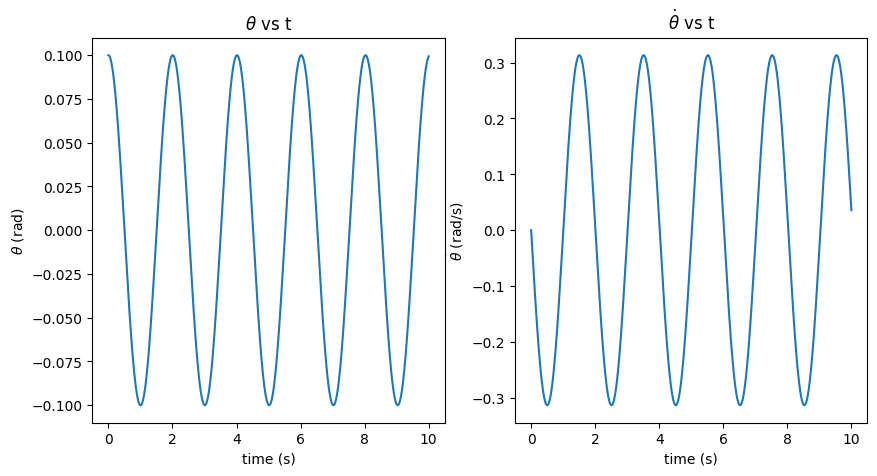

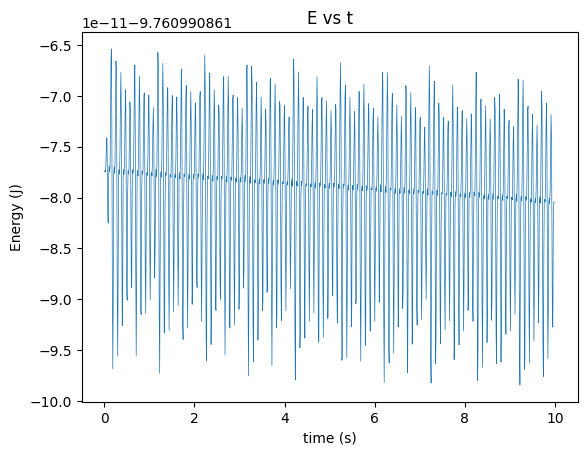

In [8]:
# Initialize Pendulum Configs class
n = 1
is_cart=False
params_single = PendulumConfig.default_params(n=n, is_cart=is_cart) # Sets all pendulum masses to 1kg and all lengths to 1m.
small_angle_ICs_single = params_single.small_angle_ICs() # Sets initial conditions to theta = .01 and theta_dot = 0
sys_single_0 = PendulumSystem(n=n, is_cart=is_cart, cfg=params_single, ICs=small_angle_ICs_single) # Initializes the PendulumSystem class for the single pendulum with small angle initial conditions and default params
sim_single_0 = sys_single_0.simulate() # Uses defaults: solver='DOP853', t_span=(0,10), dt=.01, controller=None
ke_0, pe_0, energy_single_0 = sys_single_0.energy_history() # Calculates the energy of the system at each sim.t time step

# Plot coord vs time and velocity vs time
figure, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].plot(sim_single_0.t, sim_single_0.y[0])
axes[1].plot(sim_single_0.t, sim_single_0.y[1])
for ax in axes:
    ax.set_xlabel('time (s)')
axes[0].set_ylabel(r'$\theta$ (rad)')
axes[1].set_ylabel(r'$\dot{\theta}$ (rad/s)')
axes[0].set_title(r'$\theta$ vs t')
axes[1].set_title(r'$\dot{\theta}$ vs t')
plt.show()

# Plot energy vs time
plt.plot(sim_single_0.t, energy_single_0, linewidth=.5)
plt.xlabel('time (s)')
plt.ylabel('Energy (J)')
plt.title('E vs t')
plt.show()

The $\theta$ and $\dot{\theta}$ vs $t$ plots both exhibit the classic harmonic oscillator behavior that should be expected at small angles.

The energy is constant up to 1e-10J which is expected for the default error terms set at `rtol = 1e-10` and `atol=1e-12`.

### Near vertical initial conditions verifying separation from typical harmonic oscillator behavior.

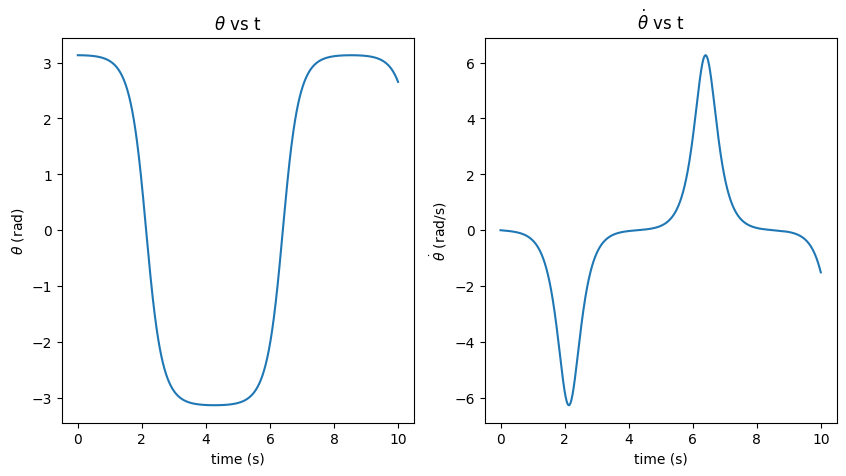

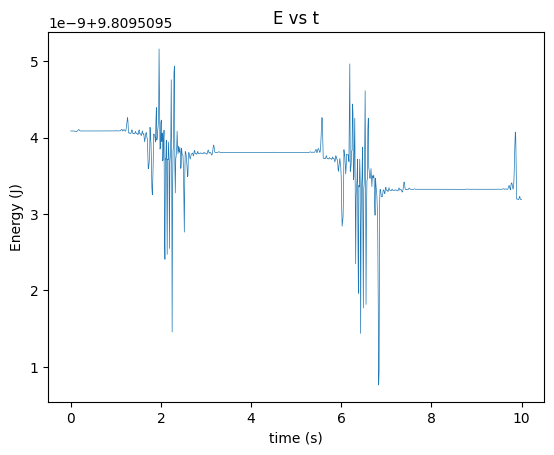

In [9]:
# Initialize Pendulum Configs class
n = 1
is_cart=False
params_single = PendulumConfig.default_params(n=n, is_cart=is_cart) # Sets all pendulum masses to 1kg and all lengths to 1m.
near_vertical_ICs_single = params_single.chaotic_ICs() # Sets initial conditions to theta = pi - eps (small parameter = .1 default) and theta_dot = 0
sys_single_1 = PendulumSystem(n=n, is_cart=is_cart, cfg=params_single, ICs=near_vertical_ICs_single) # Initializes the PendulumSystem class for the single pendulum with small angle initial conditions and default params
sim_single_1 = sys_single_1.simulate() # Uses defaults: solver='DOP853', t_span=(0,10), dt=.01, controller=None
ke_1, pe_1, energy_single_1 = sys_single_1.energy_history() # Calculates the energy of the system at each sim.t time step

# Plot coord vs time and velocity vs time
figure, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].plot(sim_single_1.t, sim_single_1.y[0])
axes[1].plot(sim_single_1.t, sim_single_1.y[1])
for ax in axes:
    ax.set_xlabel('time (s)')
axes[0].set_ylabel(r'$\theta$ (rad)')
axes[1].set_ylabel(r'$\dot{\theta}$ (rad/s)')
axes[0].set_title(r'$\theta$ vs t')
axes[1].set_title(r'$\dot{\theta}$ vs t')
plt.show()

# Plot energy vs time
plt.plot(sim_single_1.t, energy_single_1, linewidth=.5)
plt.xlabel('time (s)')
plt.ylabel('Energy (J)')
plt.title('E vs t')
plt.show()

It is very obvious that for this initial condition the linear approximation of a single pendulum would not be valid. This behavior also makes sense, due to the fact that as the pendulum mass approaches its max angle again the gravitational force has dropped significantly. However, since this is a single pendulum it never exhibits chaotic behavior.

Energy is now only conserved at the 1e-9 level but this is still sufficient to be confident the physics and simulator are interacting correctly.

## Behavior of a Single Pendulum with a Cart

Near vertical initial conditions for a single pendulum on a cart. Showing oscillation of both coordinates $x_c$ and $\theta$.

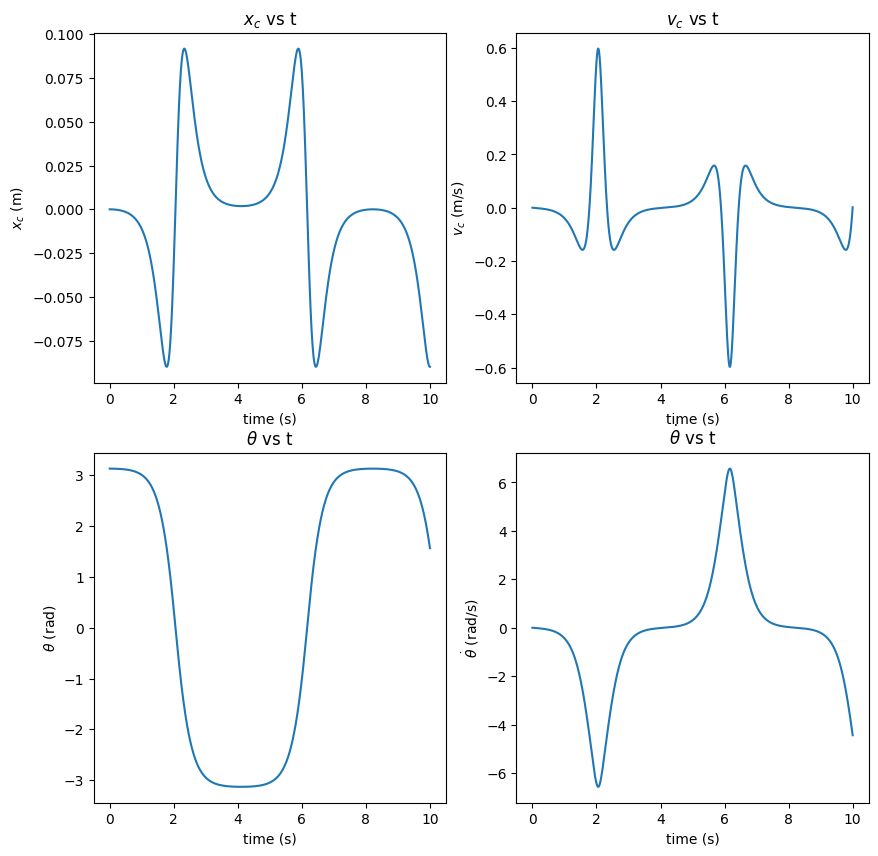

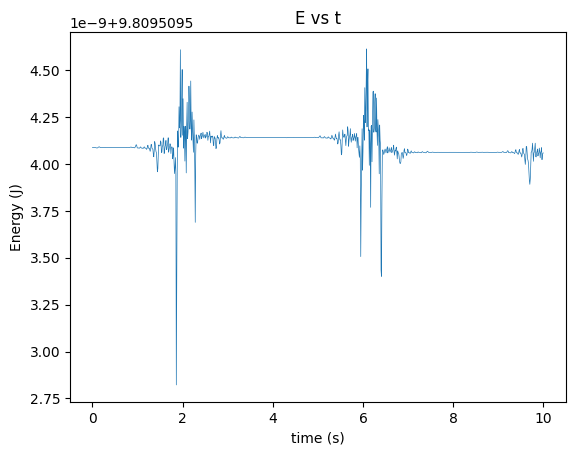

In [10]:
# Initialize Pendulum Configs class
n = 1
is_cart=True
params_single_cart = PendulumConfig.default_params(n=n, is_cart=is_cart) # Sets cart mass to 10kg and all pendulum masses to 1kg and all lengths to 1m.
near_vertical_ICs_single_cart = params_single_cart.chaotic_ICs() # Sets initial conditions to theta = pi - eps (small parameter = .1 default) and theta_dot = 0
sys_single_cart = PendulumSystem(n=n, is_cart=is_cart, cfg=params_single_cart, ICs=near_vertical_ICs_single_cart) # Initializes the PendulumSystem class for the single pendulum with small angle initial conditions and default params
sim_single_cart = sys_single_cart.simulate() # Uses defaults: solver='DOP853', t_span=(0,10), dt=.01, controller=None
ke_cart, pe_cart, energy_single_cart = sys_single_cart.energy_history() # Calculates the energy of the system at each sim.t time step

# Plot coord vs time and velocity vs time
figure, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0,0].plot(sim_single_cart.t, sim_single_cart.y[0])
axes[0,1].plot(sim_single_cart.t, sim_single_cart.y[2])
axes[1,0].plot(sim_single_cart.t, sim_single_cart.y[1])
axes[1,1].plot(sim_single_cart.t, sim_single_cart.y[3])

for i in range(n+int(is_cart)):
    axes[i,0].set_xlabel('time (s)')
    axes[i,1].set_xlabel('time (s)')
axes[0, 0].set_ylabel(r'$x_c$ (m)')
axes[0, 1].set_ylabel(r'$v_c$ (m/s)')
axes[1, 0].set_ylabel(r'$\theta$ (rad)')
axes[1, 1].set_ylabel(r'$\dot{\theta}$ (rad/s)')
axes[0, 0].set_title(r'$x_c$ vs t')
axes[0, 1].set_title(r'$v_c$ vs t')
axes[1, 0].set_title(r'$\theta$ vs t')
axes[1, 1].set_title(r'$\dot{\theta}$ vs t')
plt.show()

# Plot energy vs time
plt.plot(sim_single_cart.t, energy_single_cart, linewidth=.5)
plt.xlabel('time (s)')
plt.ylabel('Energy (J)')
plt.title('E vs t')
plt.show()

The cart position is periodic as expected and reaches its slowest velocity at the same time the pendulum bob has its slowest velocity. The control will have to balance out both of these effects to stabilize the pendulum.

## How is LQR being added to the system?

Initially, the goal was to derive the linear system exactly from the fully nonlinear system for each unstable equilibrium, however, after attempting this and having issues getting the control to work, I decided to use a centered finite difference around the chosen equilibrium to get an approximate linear system.

This allowed for an easy change of which equilibrium was being studied for the $n>1$ cases and is a good stepping stone before doing the full linear system by hand first.

The Q and R inputs for solving the riccati equation are tuning features. In general, I was able to vary them quite widely and achieve good results for range of controllable initial conditions.

## Adding pure LQR control to the single pendulum cart system.

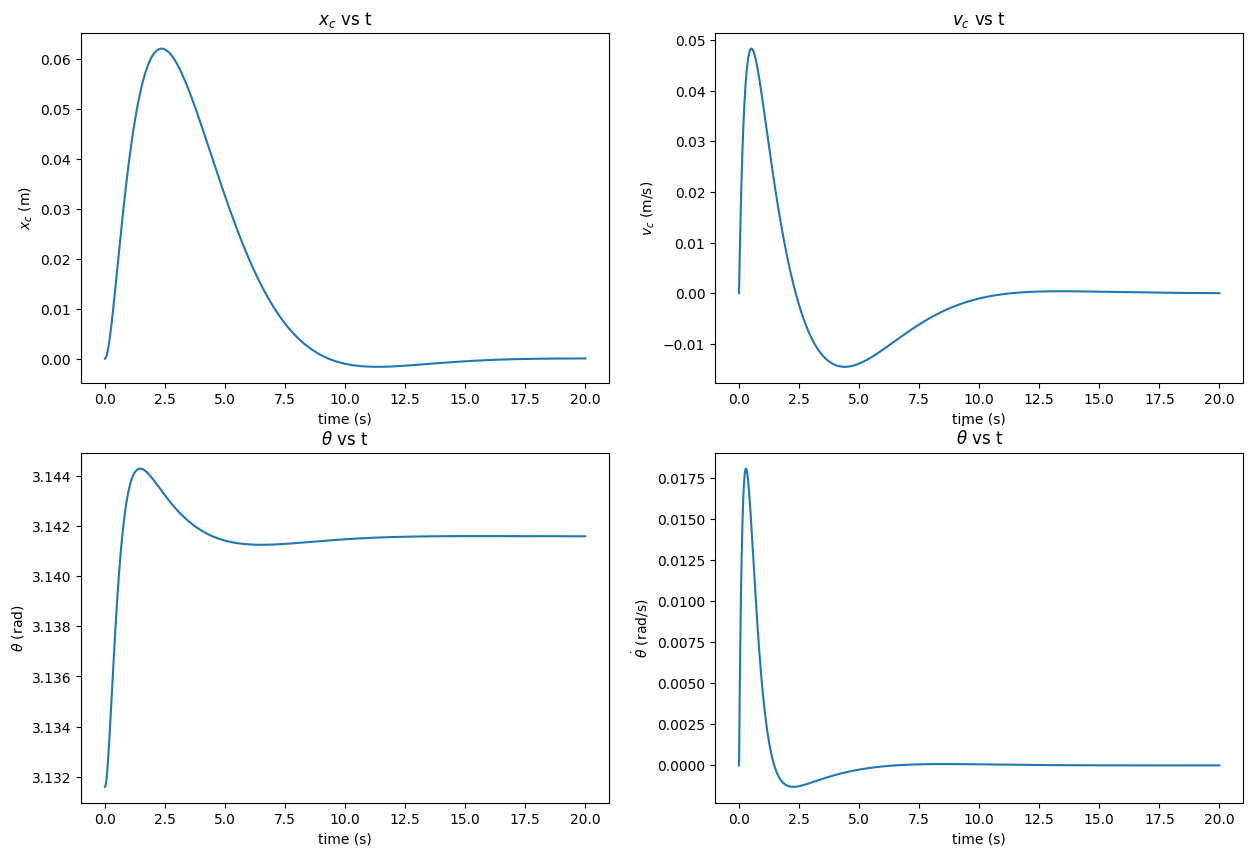

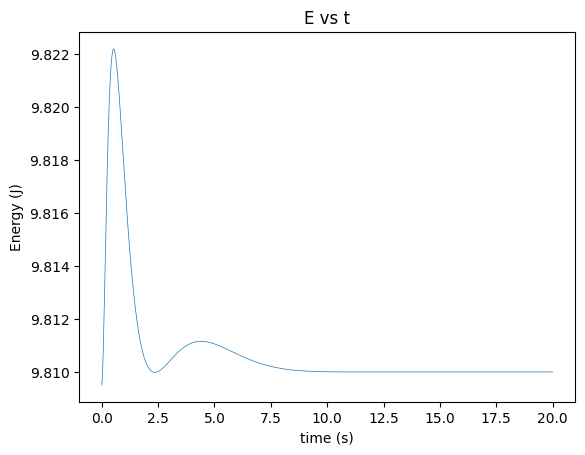

In [11]:
# Initialize Pendulum Configs class
n = 1
is_cart=True
params_controlled_single_0 = PendulumConfig.default_params(n=n, is_cart=is_cart) # Sets cart mass to 10kg and all pendulum masses to 1kg and all lengths to 1m.

near_vertical_ICs_controlled_single_0 = params_controlled_single_0.chaotic_ICs() # Sets initial conditions to theta = pi - eps (small parameter = .1 default) and theta_dot = 0

sys_controlled_single_0 = PendulumSystem(n=n, is_cart=is_cart, cfg=params_controlled_single_0, ICs=near_vertical_ICs_controlled_single_0) # Initializes the PendulumSystem class for the single pendulum with small angle initial conditions and default params

stabilized_state = np.array([0, np.pi, 0, 0]) # Upright at x=0, no initial velocities.
Q = np.diag([1, 10, 1, 1])
R = np.diag([.1])
LQR_controller = LQRController.design(system=sys_controlled_single_0, y_eq=stabilized_state, Q=Q, R=R)

sim_controlled_single_0 = sys_controlled_single_0.simulate(solver='DOP853', t_span=(0,20), dt=.01, controller=LQR_controller) # t_span = (0, 20) shows more of the control stabilization

ke_controlled_single_0, pe_controlled_single_0, energy_controlled_single_0 = sys_controlled_single_0.energy_history() # Calculates the energy of the system at each sim.t time step

# Plot coord vs time and velocity vs time
figure, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0,0].plot(sim_controlled_single_0.t, sim_controlled_single_0.y[0])
axes[0,1].plot(sim_controlled_single_0.t, sim_controlled_single_0.y[2])
axes[1,0].plot(sim_controlled_single_0.t, sim_controlled_single_0.y[1])
axes[1,1].plot(sim_controlled_single_0.t, sim_controlled_single_0.y[3])

for i in range(n+int(is_cart)):
    axes[i,0].set_xlabel('time (s)')
    axes[i,1].set_xlabel('time (s)')
axes[0, 0].set_ylabel(r'$x_c$ (m)')
axes[0, 1].set_ylabel(r'$v_c$ (m/s)')
axes[1, 0].set_ylabel(r'$\theta$ (rad)')
axes[1, 1].set_ylabel(r'$\dot{\theta}$ (rad/s)')
axes[0, 0].set_title(r'$x_c$ vs t')
axes[0, 1].set_title(r'$v_c$ vs t')
axes[1, 0].set_title(r'$\theta$ vs t')
axes[1, 1].set_title(r'$\dot{\theta}$ vs t')
plt.show()

# Plot energy vs time
plt.plot(sim_controlled_single_0.t, energy_controlled_single_0, linewidth=.5)
plt.xlabel('time (s)')
plt.ylabel('Energy (J)')
plt.title('E vs t')
plt.show()

For each of the control situations, viewing the control input force as a function of time gives insight into what kind of oscillations the control is acting against. For the single pendulum, it only acts against one oscillating coordinate. As expected the control input converges to zero very quickly once the pendulum is stabilized.

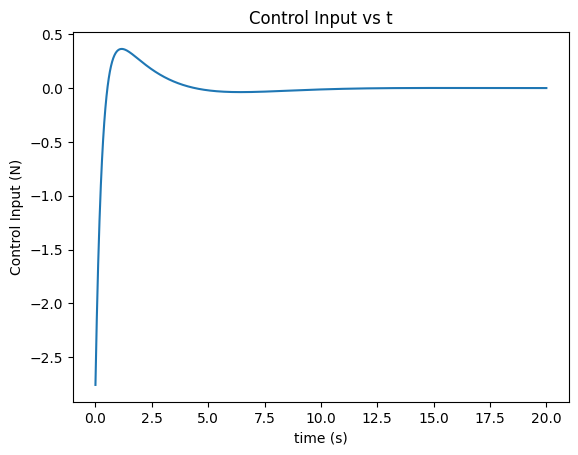

In [12]:
plt.plot(sim_controlled_single_0.t, sys_controlled_single_0.control_history)
plt.xlabel('time (s)')
plt.ylabel('Control Input (N)')
plt.title('Control Input vs t')
plt.show()

## Exploring the maximum deviation from vertical that the control force can recover to the upright position

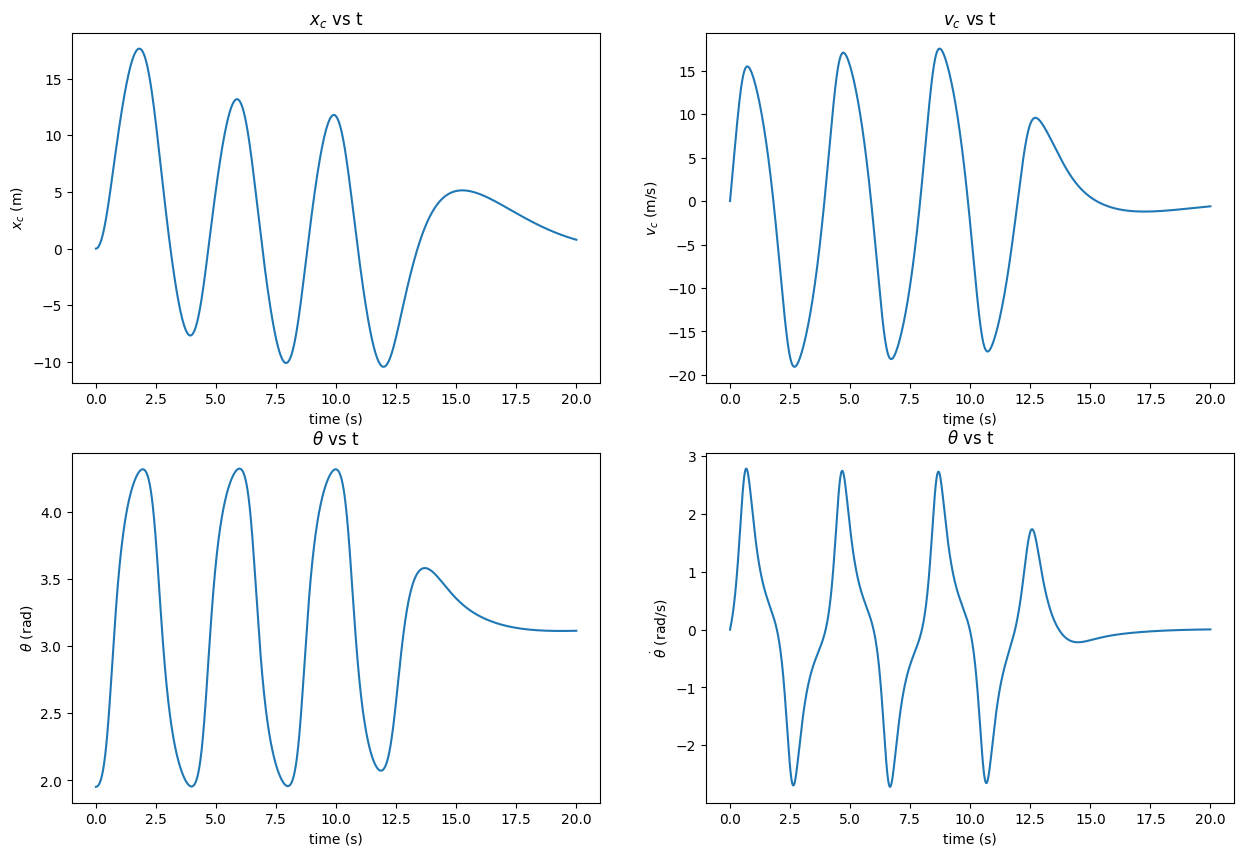

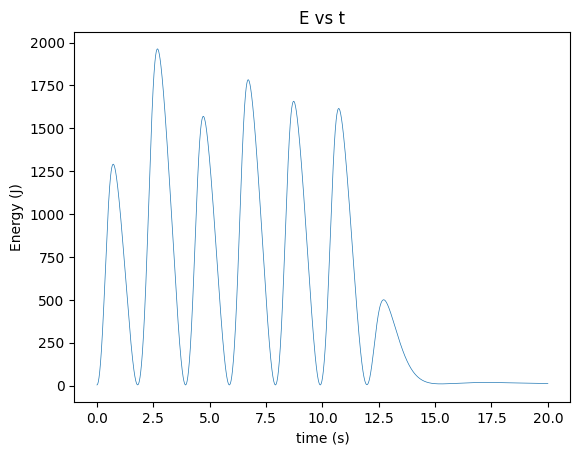

In [13]:
# Initialize Pendulum Configs class
n = 1
is_cart=True
params_controlled_single_1 = PendulumConfig.default_params(n=n, is_cart=is_cart) # Sets cart mass to 10kg and all pendulum masses to 1kg and all lengths to 1m.

eps=.381800425
stability_test_ICs_controlled_single_1 = np.array([0, np.pi/2+eps, 0, 0]) # Sets the pendulum slightly above the horizontal axis. Vary eps to test the stability region.

sys_controlled_single_1 = PendulumSystem(n=n, is_cart=is_cart, cfg=params_controlled_single_1, ICs=stability_test_ICs_controlled_single_1) # Initializes the PendulumSystem class for the single pendulum with small angle initial conditions and default params

stabilized_state = np.array([0, np.pi, 0, 0]) # Upright at x=0, no initial velocities.
Q = np.diag([1, 10, 1, 1])
R = np.diag([.1])
LQR_controller = LQRController.design(system=sys_controlled_single_1, y_eq=stabilized_state, Q=Q, R=R)

sim_controlled_single_1 = sys_controlled_single_1.simulate(solver='DOP853', t_span=(0,20), dt=.01, controller=LQR_controller) # t_span = (0, 20) shows more of the control stabilization

ke_controlled_single_1, pe_controlled_single_1, energy_controlled_single_1 = sys_controlled_single_1.energy_history() # Calculates the energy of the system at each sim.t time step

# Plot coord vs time and velocity vs time
figure, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0,0].plot(sim_controlled_single_1.t, sim_controlled_single_1.y[0])
axes[0,1].plot(sim_controlled_single_1.t, sim_controlled_single_1.y[2])
axes[1,0].plot(sim_controlled_single_1.t, sim_controlled_single_1.y[1])
axes[1,1].plot(sim_controlled_single_1.t, sim_controlled_single_1.y[3])

for i in range(n+int(is_cart)):
    axes[i,0].set_xlabel('time (s)')
    axes[i,1].set_xlabel('time (s)')
axes[0, 0].set_ylabel(r'$x_c$ (m)')
axes[0, 1].set_ylabel(r'$v_c$ (m/s)')
axes[1, 0].set_ylabel(r'$\theta$ (rad)')
axes[1, 1].set_ylabel(r'$\dot{\theta}$ (rad/s)')
axes[0, 0].set_title(r'$x_c$ vs t')
axes[0, 1].set_title(r'$v_c$ vs t')
axes[1, 0].set_title(r'$\theta$ vs t')
axes[1, 1].set_title(r'$\dot{\theta}$ vs t')
plt.show()

# Plot energy vs time
plt.plot(sim_controlled_single_1.t, energy_controlled_single_1, linewidth=.5)
plt.xlabel('time (s)')
plt.ylabel('Energy (J)')
plt.title('E vs t')
plt.show()

With by hand testing to 8 decimal places the most the pendulum can be set off of the upright vertical is $\pi/2 - .381800425 = 1.188995902\mathrm{rad}$. Adjustments any lower than this cause the system to jump into a very uncontrollable state where energies quickly diverge and the cart is sent off to infinity at ever increasing velocities. The angle does eventually approach the stable equilibrium with extremely fast but small oscillations around it due to the amount of energy put into the system.

With further testing and refining, I am confident that one could produce a system that does any integer of oscillations before coming to stability. This is obviously unphysical and more of a mathematical exploration than applied idea, however.

## The single cart pendulum with a deadband actuator enveloping the LQR control.

A more physical version of this problem uses a deadband with an on and an off limit to simulate the effects of static vs sliding friction within an actuator. The deadband takes in the LQR control input but zeros it if it is below the `deadband_on` parameter. This is the minimum force required to overcome static friction. Then if the control force dips below the on parameter, it decreases linearly as it approaches the `deadband_off` parameter simulating sliding friction preventing the input from causing motion for the actuator.

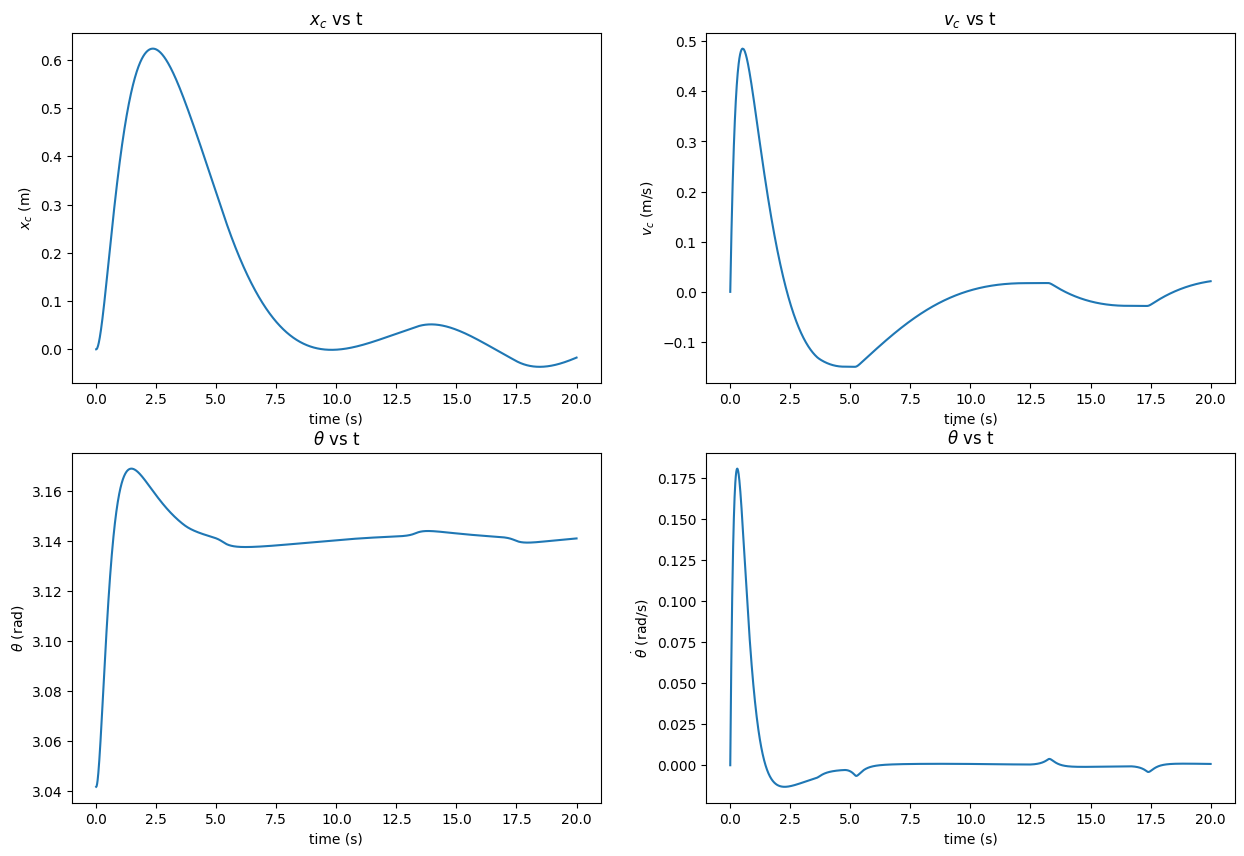

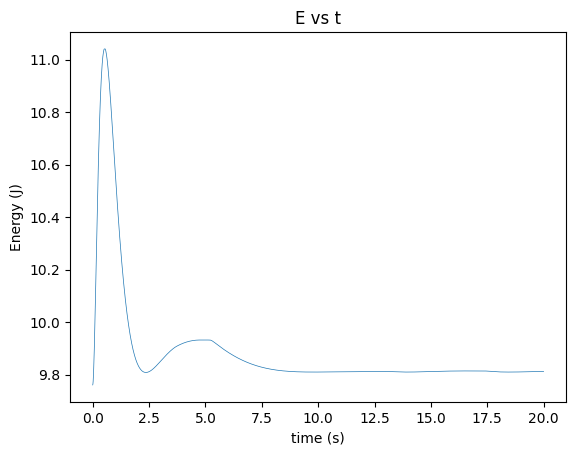

In [16]:
# Initialize Pendulum Configs class
n = 1
is_cart=True
params_controlled_single_2 = PendulumConfig.default_params(n=n, is_cart=is_cart) # Sets cart mass to 10kg and all pendulum masses to 1kg and all lengths to 1m.
stabilized_state = np.array([0, np.pi, 0, 0]) # Upright at x=0, no initial velocities.
eps = np.array([0, .1, 0, 0])
near_vertical_ICs_controlled_single_2 = stabilized_state - eps # Sets the pendulum slightly off the goal equilibrium depending on the input eps

sys_controlled_single_2 = PendulumSystem(n=n, is_cart=is_cart, cfg=params_controlled_single_2, ICs=near_vertical_ICs_controlled_single_2) # Initializes the PendulumSystem class for the single pendulum with small angle initial conditions and default params

Q = np.diag([1, 10, 1, 1])
R = np.diag([.1])
LQR_controller = DeadbandActuator(LQRController.design(system=sys_controlled_single_2, y_eq=stabilized_state, Q=Q, R=R), deadband_on=.5, deadband_off=.25)

sim_controlled_single_2 = sys_controlled_single_2.simulate(solver='DOP853', t_span=(0,20), dt=.01, controller=LQR_controller) # t_span = (0, 20) shows more of the control stabilization

ke_controlled_single_2, pe_controlled_single_2, energy_controlled_single_2 = sys_controlled_single_2.energy_history() # Calculates the energy of the system at each sim.t time step

# Plot coord vs time and velocity vs time
figure, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0,0].plot(sim_controlled_single_2.t, sim_controlled_single_2.y[0])
axes[0,1].plot(sim_controlled_single_2.t, sim_controlled_single_2.y[2])
axes[1,0].plot(sim_controlled_single_2.t, sim_controlled_single_2.y[1])
axes[1,1].plot(sim_controlled_single_2.t, sim_controlled_single_2.y[3])

for i in range(n+int(is_cart)):
    axes[i,0].set_xlabel('time (s)')
    axes[i,1].set_xlabel('time (s)')
axes[0, 0].set_ylabel(r'$x_c$ (m)')
axes[0, 1].set_ylabel(r'$v_c$ (m/s)')
axes[1, 0].set_ylabel(r'$\theta$ (rad)')
axes[1, 1].set_ylabel(r'$\dot{\theta}$ (rad/s)')
axes[0, 0].set_title(r'$x_c$ vs t')
axes[0, 1].set_title(r'$v_c$ vs t')
axes[1, 0].set_title(r'$\theta$ vs t')
axes[1, 1].set_title(r'$\dot{\theta}$ vs t')
plt.show()

# Plot energy vs time
plt.plot(sim_controlled_single_2.t, energy_controlled_single_2, linewidth=.5)
plt.xlabel('time (s)')
plt.ylabel('Energy (J)')
plt.title('E vs t')
plt.show()

The pendulum still stabilizes, but the stability is oscillatory. Instead of converging to the goal state with decaying oscillations that become small very quickly, the pendulum approaches a state of constant oscillation around the goal state with amplitude and shape depending on the deadband parameter sizes and the shape of the deadband between function.

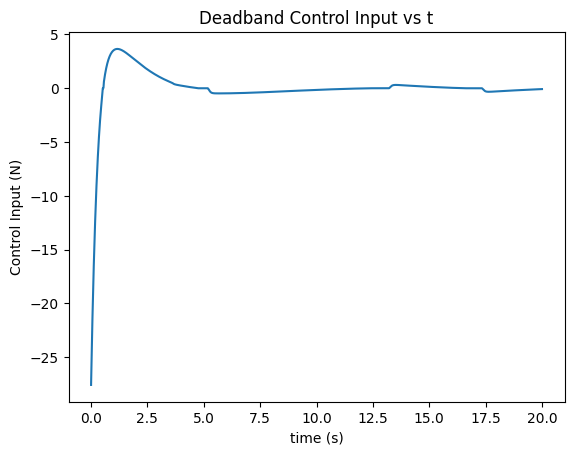

In [18]:
plt.plot(sim_controlled_single_2.t, sys_controlled_single_2.control_history)
plt.xlabel('time (s)')
plt.ylabel('Control Input (N)')
plt.title('Deadband Control Input vs t')
plt.show()

Now, we can see that the control never approaches zero and remains there. The input must vary over time around $u=0\mathrm{N}$ to maintain the stability of the state. This is more physically valid as many unstable equilibriums will diverge from stability with very minor disturbances.